## Agenda

The main goal of this notebook is to **compare the computational performance** of generating simulated sky maps **with and without bandpass integration**.  

### Objectives
-  **Baseline performance** → test with a single frequency (no BP)  
-  **Bandpass integration approaches**:  
  - Synthetic **Gaussian bandpass**  
  - Planck-provided **RIMO bandpass**  
-  **Measure and compare runtimes** across multiple runs  

### Expected Outcome
- Quantify the **additional computational cost** introduced by real bandpass integration compared to the simplified single-frequency case  

---

✅ This experiment is performed for **all presets** with **NSIDE = 2048**.


In [2]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"
sys.path.append("/bigdata/aankit/lost_in_space/")
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'



In [3]:
from astropy.config.paths import get_cache_dir
print("Astropy cache dir:", get_cache_dir())  # should print /bigdata/...whatever

Astropy cache dir: /bigdata/cmb_project/xdg_home/xdg_cache/astropy


In [11]:
from time import time
import hydra
from hydra import compose, initialize

from omegaconf import OmegaConf

from cmbml.utils.planck_instrument import make_instrument
from cmbml_utils import PipeAccessor  # make sure to add ../lost_in_space to sys.path

import pysm3
import pysm3.units as u

import numpy as np

from time import time

from cmbml.core.asset_handlers import HealpyMap

In [12]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None)
cfg = compose(config_name='config_sim', overrides=["+min_obs_beam=0"])  # Only used for the instrument
pa = PipeAccessor(cfg, "raw_in")
sim_det_info = pa.assets_in['deltabandpass'].read()
SIM_INSTRUMENT = make_instrument(cfg=cfg,
                                 det_info=sim_det_info)

In [13]:
PRESET_STRINGS = ["co1",
    "c2",    # c2 is a realization created with CMBLensed
    "d9",    # d9 is recommended by Simons Observatory in the "low complexity foregrounds"
    "s4",    # d9 is recommended by Simons Observatory in the "low complexity foregrounds"
    "f1",    # only option
    "a1",    # only option
    "cib1",  # cib1 is recommended by Simons Observatory for extragalactic components
    "ksz1",  # ksz1 is recommended by Simons Observatory for extragalactic components
    "tsz1",  # tsz1 is recommended by Simons Observatory for extragalactic components
    "rg1"    # rg1 is recommended by Simons Observatory for extragalactic components
]

NSIDE_SKY = 2048  # Should be at least 2 * NSIDE_OUT
NSIDE_OUT = 512

# # Used when making 128 maps
# NSIDE_SKY = 256  # Should be at least 2 * NSIDE_OUT
# NSIDE_OUT = 128

start_time = time()

sky = pysm3.Sky(preset_strings=PRESET_STRINGS, 
                nside=NSIDE_SKY, 
                output_unit=pysm3.units.uK_CMB)

print(f"{time()-start_time:.0f}s")

93s


In [ ]:
runs = 10
selected_freqs = [30, 100, 857] # choosing arbitray frequencies to test
detectors = [d for d in SIM_INSTRUMENT.dets.values() if d.nom_freq in selected_freqs]
detectors

[Detector(nom_freq=30, fields='I', cen_freq=<Quantity 28.4 GHz>, fwhm=<Quantity 75. arcmin>),
 Detector(nom_freq=100, fields='I', cen_freq=<Quantity 100.89 GHz>, fwhm=<Quantity 43. arcmin>),
 Detector(nom_freq=857, fields='I', cen_freq=<Quantity 866.8 GHz>, fwhm=<Quantity 20.6 arcmin>)]

In [7]:
def make_bandpass(center, width=1.0*u.GHz, n_points=50):
    freqs = center + np.linspace(-3, 3, n_points) * width
    weights = np.exp(-0.5 * ((freqs - center)/width)**2)
    weights /= np.sum(weights)
    return freqs, weights

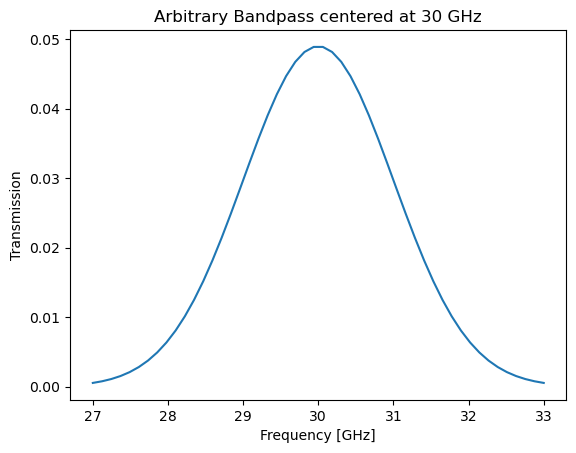

In [8]:
freqs, weights = make_bandpass(30*u.GHz)
import matplotlib.pyplot as plt
plt.plot(freqs, weights)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Transmission")
plt.title("Arbitrary Bandpass centered at 30 GHz")
plt.show()

## Warming up

In [ ]:
start_time = time()
_ = sky.get_emission(detectors[0].cen_freq)

freqs, weights = make_bandpass(30*u.GHz, width=1*u.GHz, n_points=50) # random freqs and weights
_ = sky.get_emission(freqs, weights)
print(f"Warm-up time: {time()-start_time:.1f}s")

Warm-up time: 660.9s


## Timinig without bandpass

In [ ]:
start_time = time()
for run in range(runs):
    run_start = time()
    no_bpi_maps = {}
    for det in detectors:
        t0 = time()
        no_bpi_maps[det.nom_freq] = sky.get_emission(det.cen_freq)
        print(f"        No BP: {det.nom_freq} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-run_start:.2f}s")
print(f"Total no BP time: {time()-start_time:.0f}s")

        No BP: 30 GHz -> 17.56s
        No BP: 100 GHz -> 90.97s
        No BP: 857 GHz -> 16.71s
    Run 1/10 time taken: 125.24s
        No BP: 30 GHz -> 17.15s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.24s
    Run 2/10 time taken: 51.56s
        No BP: 30 GHz -> 17.29s
        No BP: 100 GHz -> 17.27s
        No BP: 857 GHz -> 16.92s
    Run 3/10 time taken: 51.48s
        No BP: 30 GHz -> 17.49s
        No BP: 100 GHz -> 17.58s
        No BP: 857 GHz -> 16.88s
    Run 4/10 time taken: 51.96s
        No BP: 30 GHz -> 17.56s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.39s
    Run 5/10 time taken: 52.12s
        No BP: 30 GHz -> 17.92s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.20s
    Run 6/10 time taken: 52.29s
        No BP: 30 GHz -> 17.99s
        No BP: 100 GHz -> 17.13s
        No BP: 857 GHz -> 16.85s
    Run 7/10 time taken: 51.98s
        No BP: 30 GHz -> 17.53s
        No BP: 100 GHz -> 17.22s
        No BP: 857 GHz -

## Timing with arbitrary bandpass

In [47]:
start_time = time()

for run in range(runs):
    run_start = time()
    bpi_maps = {}
    for det in detectors:
        t0 = time()
        freqs, weights = make_bandpass(det.cen_freq)
        bpi_maps[det.nom_freq] = sky.get_emission(freqs, weights)
        print(f"        With BP: {det.nom_freq} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-run_start:.2f}s")
print(f"Total with BP time: {time()-start_time:.2f}s")

        With BP: 30 GHz -> 115.43s
        With BP: 100 GHz -> 156.62s
        With BP: 857 GHz -> 114.66s
    Run 1/10 time taken: 386.71s
        With BP: 30 GHz -> 118.80s
        With BP: 100 GHz -> 117.72s
        With BP: 857 GHz -> 114.88s
    Run 2/10 time taken: 351.40s
        With BP: 30 GHz -> 117.19s
        With BP: 100 GHz -> 117.90s
        With BP: 857 GHz -> 118.79s
    Run 3/10 time taken: 353.88s
        With BP: 30 GHz -> 122.63s
        With BP: 100 GHz -> 116.85s
        With BP: 857 GHz -> 112.23s
    Run 4/10 time taken: 351.72s
        With BP: 30 GHz -> 116.16s
        With BP: 100 GHz -> 119.94s
        With BP: 857 GHz -> 112.78s
    Run 5/10 time taken: 348.88s
        With BP: 30 GHz -> 114.91s
        With BP: 100 GHz -> 114.26s
        With BP: 857 GHz -> 109.75s
    Run 6/10 time taken: 338.93s
        With BP: 30 GHz -> 114.59s
        With BP: 100 GHz -> 114.88s
        With BP: 857 GHz -> 112.07s
    Run 7/10 time taken: 341.54s
        With BP: 30 

## Simulating with real values RIMO LFI

Link - https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/

In [9]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

filename = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
hdul = fits.open(filename)

bandpass_hdu = hdul['BANDPASS_030-28S']

# Print the column names to see what they are
print(bandpass_hdu.columns.names)
# Example output: ['FREQ', 'RESPONSE', 'WEIGHT', 'NAME'] or similar


['WAVENUMBER', 'TRANSMISSION', 'UNCERTAINITY', 'FLAG']


In [10]:
hdul.info()

Filename: /bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  CHANNEL_PARAMETERS    1 BinTableHDU     62   22R x 15C   [8A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  FREQUENCY_MAP_PARAMETERS    1 BinTableHDU     48   3R x 10C   [3A, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  3  BANDPASS_030-28S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  4  BANDPASS_030-28M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  5  BANDPASS_030-27S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  6  BANDPASS_030-27M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  7  BANDPASS_044-26S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  8  BANDPASS_044-26M    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  9  BANDPASS_044-25S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
 10  BANDPASS_044-25M    1 BinTab

In [11]:
bandpass_names = [hdu.name for hdu in hdul if hdu.name and hdu.name.startswith("BANDPASS_")]
print(len(bandpass_names))
bandpass_names

25


['BANDPASS_030-28S',
 'BANDPASS_030-28M',
 'BANDPASS_030-27S',
 'BANDPASS_030-27M',
 'BANDPASS_044-26S',
 'BANDPASS_044-26M',
 'BANDPASS_044-25S',
 'BANDPASS_044-25M',
 'BANDPASS_044-24S',
 'BANDPASS_044-24M',
 'BANDPASS_070-23S',
 'BANDPASS_070-23M',
 'BANDPASS_070-22S',
 'BANDPASS_070-22M',
 'BANDPASS_070-21S',
 'BANDPASS_070-21M',
 'BANDPASS_070-20S',
 'BANDPASS_070-20M',
 'BANDPASS_070-19S',
 'BANDPASS_070-19M',
 'BANDPASS_070-18S',
 'BANDPASS_070-18M',
 'BANDPASS_030',
 'BANDPASS_044',
 'BANDPASS_070']

### Number of entries per detector

In [12]:
bandpass_names = [hdu.name for hdu in hdul if hdu.name and hdu.name.startswith("BANDPASS_")]

for name in bandpass_names:
    data = hdul[name].data
    freqs = data["WAVENUMBER"]   # GHz
    resp = data["TRANSMISSION"]     # dimensionless
    print(f"{name}: Number of freqs = {len(freqs)}, Number of weights = {len(resp)}")




BANDPASS_030-28S: Number of freqs = 188, Number of weights = 188
BANDPASS_030-28M: Number of freqs = 188, Number of weights = 188
BANDPASS_030-27S: Number of freqs = 188, Number of weights = 188
BANDPASS_030-27M: Number of freqs = 188, Number of weights = 188
BANDPASS_044-26S: Number of freqs = 151, Number of weights = 151
BANDPASS_044-26M: Number of freqs = 151, Number of weights = 151
BANDPASS_044-25S: Number of freqs = 151, Number of weights = 151
BANDPASS_044-25M: Number of freqs = 151, Number of weights = 151
BANDPASS_044-24S: Number of freqs = 151, Number of weights = 151
BANDPASS_044-24M: Number of freqs = 151, Number of weights = 151
BANDPASS_070-23S: Number of freqs = 251, Number of weights = 251
BANDPASS_070-23M: Number of freqs = 251, Number of weights = 251
BANDPASS_070-22S: Number of freqs = 251, Number of weights = 251
BANDPASS_070-22M: Number of freqs = 251, Number of weights = 251
BANDPASS_070-21S: Number of freqs = 251, Number of weights = 251
BANDPASS_070-21M: Number 

### Converting wavenumber to frequencies and extracting corresponding weights for LFI

In [19]:
bandpass_hdu = hdul['BANDPASS_030']

c_cm_s = 2.99792458e10  # speed of light in cm/s
freqs = (bandpass_hdu.data['WAVENUMBER'] * c_cm_s / 1e9)*u.GHz
weights = bandpass_hdu.data['TRANSMISSION']
weights /= np.sum(weights)

In [20]:
len(freqs)

188

## Timing with RIMO LFI values

Using only 30GHz for now

Stopped after Run 3 as it takes a long time just for one freq

In [ ]:
run = 10

for run in range(runs):
    t0 = time()
    maps_rimo = {}
    
    maps_rimo[bandpass_hdu.name] = sky.get_emission(freqs, weights) 
    print(f"        With BP: {int(bandpass_hdu.name[-3:])} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-t0:.2f}s")
print(f"Total with BP time: {time()-start_time:.2f}s")

/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/pysm3/models/interpolating.py:173: UserWarning: Frequency not supported, requested 1199.169832 Ghz > upper bound 1080.0 GHz
  warnings.warn(
/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/pysm3/models/interpolating.py:173: UserWarning: Frequency not supported, requested 1199.169832 Ghz > upper bound 1080.0 GHz
  warnings.warn(


        With BP: 30 GHz -> 1612.41s
    Run 1/10 time taken: 1612.41s
        With BP: 30 GHz -> 1557.22s
    Run 2/10 time taken: 1557.22s
        With BP: 30 GHz -> 1583.70s
    Run 3/10 time taken: 1583.70s


### Freqs vs Weights spread for BANDPASS_030

Unsure why the spread isnt around 30GHz. 
Sanity checks done till now:
 - Checked the header files to ensure the unit is in GHz and not MHz
 - Used two methods (normal conversion and Astropy spectral equivalencies) to convert wavenumber to frequency to ensure correct conversion
 - Checked the freq min/max range for corresponding bandpass values

Conclusion: 
The plot is peaking around ~800 GHz, not anywhere near 30GHz. Maybe these values are not the actual 30GHz detector response but rather some kinda calibration or normalization curve stored in RIMO? Im unsure about this.

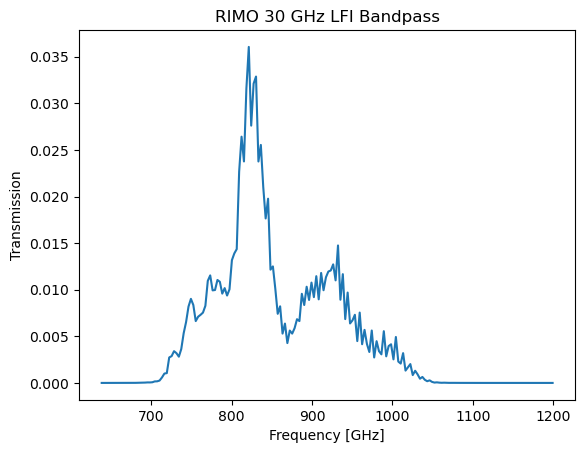

In [38]:
import matplotlib.pyplot as plt
plt.plot(freqs, weights)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Transmission")
plt.title(f"RIMO {int(bandpass_hdu.name[-3:])} GHz LFI Bandpass")
plt.show()

## Extra checks

In [7]:
from astropy.io import fits
filename = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
hdul = fits.open(filename)

for name in ["BANDPASS_030","BANDPASS_044","BANDPASS_070"]:
    h = hdul[name].header
    print("----", name, "----")
    # useful header keywords to check
    for k in ["TFORM1","TUNIT1","TTYPE1","TUNIT2","TTYPE2","BUNIT","COMMENT"]:
        if k in h: print(k, ":", h[k])
    print()

---- BANDPASS_030 ----
TFORM1 : 1D
TUNIT1 : GHz
TTYPE1 : WAVENUMBER
TUNIT2 : n/a
TTYPE2 : TRANSMISSION
COMMENT : ---------------------------------------------
    Original Inputs
---------------------------------------------
LFI_instrumentDB_13.0
LFI QUCS_20091109 BANDPASS Corrected +0.05

---- BANDPASS_044 ----
TFORM1 : 1D
TUNIT1 : GHz
TTYPE1 : WAVENUMBER
TUNIT2 : n/a
TTYPE2 : TRANSMISSION
COMMENT : ---------------------------------------------
    Original Inputs
---------------------------------------------
LFI_instrumentDB_13.0
LFI QUCS_20091109 BANDPASS Corrected +0.05

---- BANDPASS_070 ----
TFORM1 : 1D
TUNIT1 : GHz
TTYPE1 : WAVENUMBER
TUNIT2 : n/a
TTYPE2 : TRANSMISSION
COMMENT : ---------------------------------------------
    Original Inputs
---------------------------------------------
LFI_instrumentDB_13.0
LFI QUCS_20091109 BANDPASS Corrected +0.05



In [8]:
from astropy import units as u
import numpy as np

hdu = hdul['BANDPASS_030']              # pick one
wavenumber = hdu.data['WAVENUMBER']     # numeric array
trans = hdu.data['TRANSMISSION'].astype(float)

# treat it as 1/cm then convert with spectral equivalency
wn = wavenumber * (1.0 / u.cm)          # quantity in 1/cm
freqs = wn.to(u.GHz, equivalencies=u.spectral())  # proper conversion

print("Wavenumber min/max:", wn.min(), wn.max())
print("Freqs min/max (GHz):", freqs.min(), freqs.max())

Wavenumber min/max: 21.3 1 / cm 40.0 1 / cm
Freqs min/max (GHz): 638.55793554 GHz 1199.169832 GHz


### Checking details for RIMO HFI

In [9]:
filename_hfi = "/bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits"
hdul_hfi = fits.open(filename_hfi)
hdul_hfi.info()

Filename: /bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  HFI_RIMO      1 PrimaryHDU      14   ()      
  1  MAP_PARAMS    1 BinTableHDU     50   6R x 10C   [3A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  3  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  4  BANDPASS_F143    1 BinTableHDU     28   12602R x 3C   [1E, 1E, 1A]   
  5  BANDPASS_F217    1 BinTableHDU     28   12600R x 3C   [1E, 1E, 1A]   
  6  BANDPASS_F353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
  7  BANDPASS_F545    1 BinTableHDU     28   13938R x 3C   [1E, 1E, 1A]   
  8  BANDPASS_F857    1 BinTableHDU     28   16819R x 3C   [1E, 1E, 1A]   
  9  BANDPASS_PSB353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   


In [ ]:
bandpass_names = [hdu.name for hdu in hdul_hfi if hdu.name and hdu.name.startswith("BANDPASS_")]

for name in bandpass_names:
    data = hdul_hfi[name].data
    freqs = data["WAVENUMBER"]   
    resp = data["TRANSMISSION"]     
    print(f"{name}: Number of freqs = {len(freqs)}, Number of weights = {len(resp)}")

BANDPASS_F100: Number of freqs = 12297, Number of weights = 12297
BANDPASS_F100: Number of freqs = 12297, Number of weights = 12297
BANDPASS_F143: Number of freqs = 12602, Number of weights = 12602
BANDPASS_F217: Number of freqs = 12600, Number of weights = 12600
BANDPASS_F353: Number of freqs = 12930, Number of weights = 12930
BANDPASS_F545: Number of freqs = 13938, Number of weights = 13938
BANDPASS_F857: Number of freqs = 16819, Number of weights = 16819
BANDPASS_PSB353: Number of freqs = 12930, Number of weights = 12930
